# SOB4ES - Modelo XGBoost

### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluación de los modelos

Este notebook recorre el ciclo de vida completo del modelo XGBoost.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por país)
- `test.csv` - Búsqueda de hiperparámetros y validación cruzada (15 %)
- `eval.csv` - Evaluación final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. **Configuración:** importaciones y parámetros globales.
2. **Carga de datos:** se cargan los tres splits pre-generados.
3. **Tuning:** búsqueda del valor óptimo de los hiperparámetros.
4. **Validación cruzada:** evaluación de robustez.
5. **Explicabilidad (SHAP):** análisis de importancia de variables.
6. **Producción:** entrenamiento final y exportación de modelos.
7. **Evaluación final:** rendimiento real sobre `eval.csv`.

## 1.- Configuración del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

import itertools

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

import shap
import xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, KFold, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ignoramos los warnings
warnings.filterwarnings('ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/xgb'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)


Librerias y variables cargadas correctamente...


In [2]:

# Deteccion de GPU / CUDA

# Comprueba si hay una GPU NVIDIA disponible y, en ese caso, configura
# XGBoost para usarla automaticamente. Si no hay GPU (o XGBoost no fue
# compilado con soporte CUDA), se usa la CPU sin que falle nada.

import subprocess

def _detectar_cuda():
    """Comprueba si hay una GPU NVIDIA con drivers CUDA disponibles en el sistema."""
    try:
        resultado = subprocess.run(
            ['nvidia-smi'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            timeout=5,
        )
        return resultado.returncode == 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return False

def _xgb_soporta_device():
    """XGBoost >= 2.0 usa el parametro 'device'; las versiones anteriores
    activan la GPU unicamente con tree_method='gpu_hist'."""
    try:
        return int(xgboost.__version__.split('.')[0]) >= 2
    except Exception:
        return False

CUDA_DISPONIBLE = _detectar_cuda()

if CUDA_DISPONIBLE and _xgb_soporta_device():
    # XGBoost >= 2.0: GPU via tree_method='hist' + device='cuda'
    XGB_DEVICE_PARAMS = {'tree_method': 'hist', 'device': 'cuda'}
elif CUDA_DISPONIBLE:
    # XGBoost < 2.0: GPU via tree_method='gpu_hist'
    XGB_DEVICE_PARAMS = {'tree_method': 'gpu_hist'}
else:
    XGB_DEVICE_PARAMS = {'tree_method': 'hist'}

print(f'GPU NVIDIA / CUDA detectada : {CUDA_DISPONIBLE}')
print(f'Version de XGBoost          : {xgboost.__version__}')
print(f'Parametros de dispositivo   : {XGB_DEVICE_PARAMS}')
if CUDA_DISPONIBLE:
    print('XGBoost usará la GPU para el tuning, la validacion y el entrenamiento de produccion...')
else:
    print('No se detecto GPU. XGBoost usara CPU (tree_method=\'hist\')...')

# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)
import os

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

GPU NVIDIA / CUDA detectada : True
Version de XGBoost          : 3.3.0
Parametros de dispositivo   : {'tree_method': 'hist', 'device': 'cuda'}
XGBoost usará la GPU para el tuning, la validacion y el entrenamiento de produccion...
Nucleos disponibles: 16 | n_jobs asignado: 12


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la división 70/15/15 estratificada por país.

| Archivo     | Uso                                      | Filas aprox. |
| ----------- | ---------------------------------------- | ------------ |
| `train.csv` | Ajuste del modelo                        | 299          |
| `test.csv`  | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv`  | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimación imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Búsqueda de hiperparámetros (Tuning)

Se realiza una búsqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparámetros del modelo XGBoost. 

La búsqueda se ejecuta exclusivamente sobre `X_train` para evitar cualquier fuga de información hacia los splits de validación y evaluación.

Como variable objetivo de referencia se usa `earthworm_shannon_z` (lombrices de tierra).

Se hacen uso de las siguientes medidas para reducir el sobreajuste:
- **Grid mas conservador:** `max_depth` maximo 4, `n_estimators` maximo 300.
- **Regularizacion L1/L2:** se añaden `reg_alpha` y `reg_lambda` al grid.
- **Early stopping:** el entrenamiento para cuando el rendimiento en `X_test` deja de mejorar durante 20 iteraciones consecutivas.


Iniciando busqueda de hiperparametros (Tuning) para cada target...
Este proceso puede tardar bastante...



  [ 1/21] nematode_shannon_z             R2 CV: 0.1469 | Tiempo:  41.4s


  [ 2/21] macro_shannon_z                R2 CV: 0.1944 | Tiempo:  39.1s


  [ 3/21] earthworm_shannon_z            R2 CV: 0.4408 | Tiempo:  40.6s


  [ 4/21] orib_shannon_z                 R2 CV: 0.0714 | Tiempo:  38.9s


...

  [17/21] bac_asv_richness_z             R2 CV: 0.0697 | Tiempo:  38.3s


  [18/21] fun_asv_richness_z             R2 CV: -0.0178 | Tiempo:  38.1s


  [19/21] euk_asv_richness_z             R2 CV: 0.2047 | Tiempo:  39.3s


  [20/21] oomy_asv_richness_z            R2 CV: 0.2295 | Tiempo:  40.2s


  [21/21] cerc_asv_richness_z            R2 CV: 0.1954 | Tiempo:  40.0s

Tuning por target completado en 13.8 minutos.



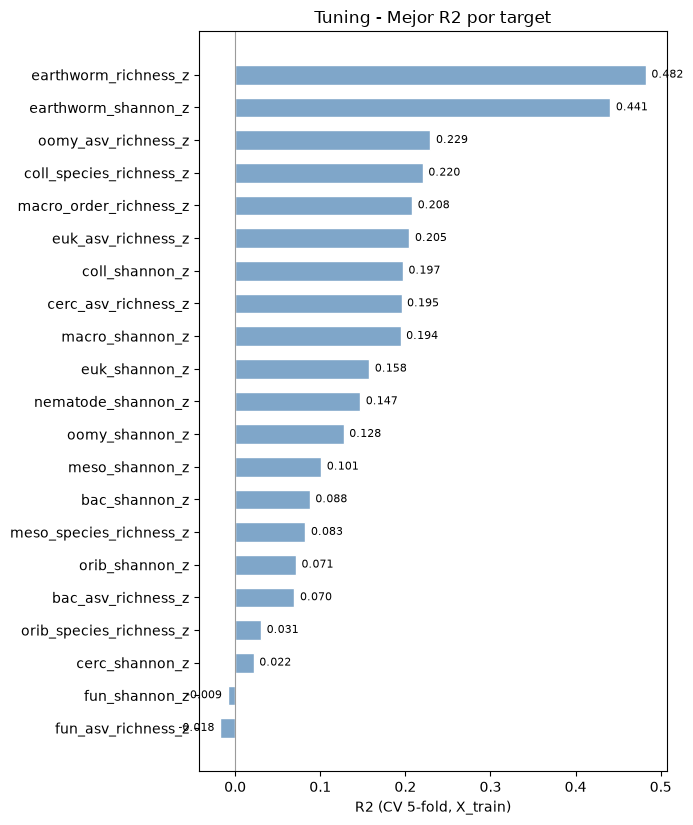

In [4]:
print("Iniciando busqueda de hiperparametros (Tuning) para cada target...")
print("Este proceso puede tardar bastante...\n")

param_grid = {
	'n_estimators':     [50, 100, 150],
	'max_depth':        [2, 3],
	'learning_rate':    [0.01, 0.05],
	'subsample':        [0.4, 0.5, 0.6],
	'colsample_bytree': [0.3, 0.4, 0.5],
	'gamma':            [1.0, 5.0, 10.0],
	'min_child_weight': [10, 20, 30],
	'reg_alpha':        [5.0, 10.0, 20.0],
	'reg_lambda':       [10.0, 20.0, 50.0],
	'grow_policy':      ['depthwise'],
	'tree_method':      [XGB_DEVICE_PARAMS['tree_method']],
	'random_state':     [RANDOM_STATE],
}

if 'device' in XGB_DEVICE_PARAMS:
    param_grid['device'] = [XGB_DEVICE_PARAMS['device']]

XGB_OPTIMAL_PARAMS_PER_TARGET = {}
resultados_tuning = {}
global_start = time.time()

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y_prueba = y_train[target_col].values

    buscador = RandomizedSearchCV(
        estimator=XGBRegressor(**XGB_DEVICE_PARAMS, random_state=RANDOM_STATE),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2',
        cv=5,
        verbose=0,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    )
    buscador.fit(X_train, y_prueba)

    params_target = dict(buscador.best_params_)
    params_target.update(XGB_DEVICE_PARAMS)
    params_target['random_state'] = RANDOM_STATE

    XGB_OPTIMAL_PARAMS_PER_TARGET[target_col] = params_target
    resultados_tuning[target_col] = {'params': params_target, 'r2': buscador.best_score_}

    print(f"  [{idx:2d}/{len(TARGETS)}] {target_col:30} R2 CV: {buscador.best_score_:.4f} | Tiempo: {time.time()-t0:>5.1f}s")

print(f"\nTuning por target completado en {(time.time() - global_start) / 60:.1f} minutos.\n")

# Grafico: R2 de tuning por target (ordenado)
_tuning_r2 = {t: resultados_tuning[t]['r2'] for t in TARGETS}
_orden = sorted(_tuning_r2, key=_tuning_r2.get)
fig, ax = plt.subplots(figsize=(7, 0.35 * len(_orden) + 1))
_bars = ax.barh([t for t in _orden], [_tuning_r2[t] for t in _orden], color=PALETTE['blue'], edgecolor='white', height=0.6)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4.- Validación cruzada

Se evalua la robustez del modelo mediante **validación cruzada repetida** (5 pliegues x 3 repeticiones = 15 evaluaciones) aplicada sobre `X_train`. 

Esto permite detectar sobreajuste comparando el rendimiento en entrenamiento y en los pliegues de validación.

In [5]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train, por target)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

print(f"{'TARGET':<25} | {'TRAIN R2':<10} | {'CV R2':<10} | {'DIFF':<10} | {'ESTADO'}")
print("-" * 75)

for nombre_target in TARGETS:
    y_prueba = y_train[nombre_target].values
    modelo_evaluacion = XGBRegressor(**XGB_OPTIMAL_PARAMS_PER_TARGET[nombre_target])

    resultados_examen = cross_validate(
        estimator=modelo_evaluacion,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True
    )

    r2_entrenamiento = np.mean(resultados_examen['train_r2'])
    r2_examen_real   = np.mean(resultados_examen['test_r2'])
    diferencia       = r2_entrenamiento - r2_examen_real

    estado = 'Aviso: Posible sobreajuste' if diferencia > 0.15 else 'OK'

    print(f"{nombre_target:<25} | {r2_entrenamiento:<10.3f} | {r2_examen_real:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida (15 evaluaciones sobre X_train, por target)...

TARGET                    | TRAIN R2   | CV R2      | DIFF       | ESTADO
---------------------------------------------------------------------------


nematode_shannon_z        | 0.395      | 0.175      | 0.221      | Aviso: Posible sobreajuste


macro_shannon_z           | 0.412      | 0.193      | 0.219      | Aviso: Posible sobreajuste


earthworm_shannon_z       | 0.588      | 0.398      | 0.190      | Aviso: Posible sobreajuste


orib_shannon_z            | 0.268      | 0.079      | 0.189      | Aviso: Posible sobreajuste


...

bac_asv_richness_z        | 0.299      | 0.030      | 0.269      | Aviso: Posible sobreajuste


fun_asv_richness_z        | 0.070      | -0.017     | 0.086      | OK


euk_asv_richness_z        | 0.434      | 0.213      | 0.221      | Aviso: Posible sobreajuste


oomy_asv_richness_z       | 0.440      | 0.220      | 0.220      | Aviso: Posible sobreajuste


cerc_asv_richness_z       | 0.432      | 0.223      | 0.209      | Aviso: Posible sobreajuste


## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (SHapley Additive exPlanations) para identificar que variables influyen más en las predicciones del modelo y en que dirección lo hacen.

El gráfico de puntos muestra las 10 variables más importantes:
- Las variables se ordenan de mayor a menor importancia global (de arriba a abajo).
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posición horizontal indica el efecto sobre la prediccion (derecha = aumenta el índice, izquierda = lo reduce).

Calculando valores SHAP sobre X_train...
Top 10 variables por importancia SHAP (earthworm_shannon_z):


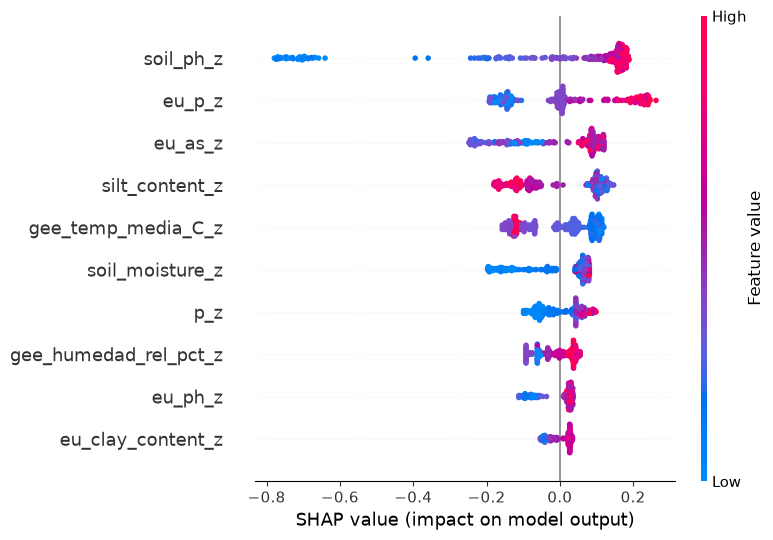

Top 10 variables por importancia SHAP (earthworm_richness_z):


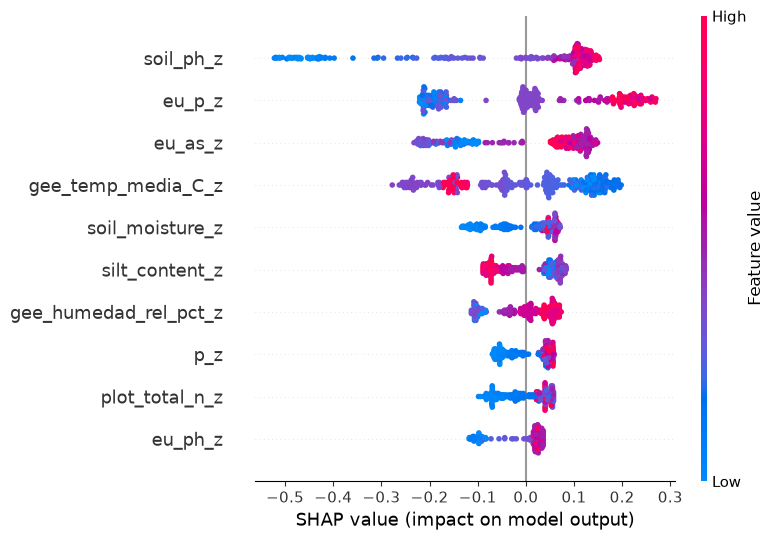

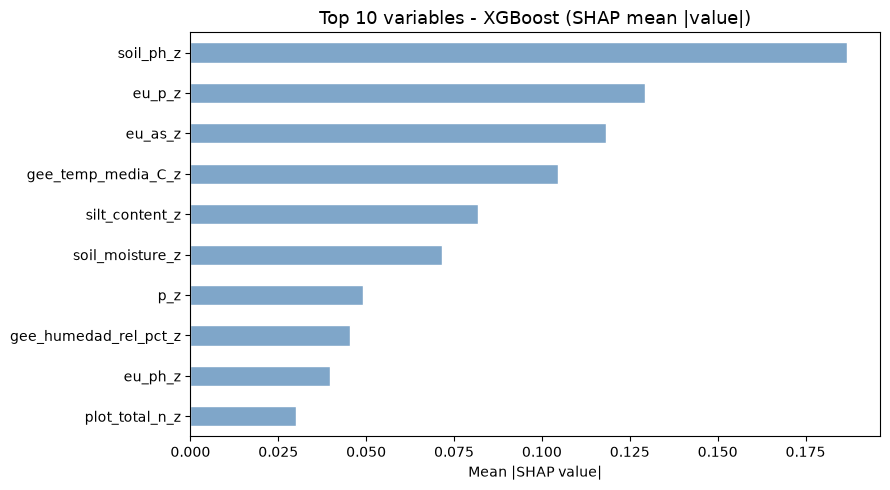

In [6]:
%matplotlib inline

print("Calculando valores SHAP sobre X_train...")

# Shannon

modelo_explicable_shannon = XGBRegressor(**XGB_OPTIMAL_PARAMS_PER_TARGET['earthworm_shannon_z'])
modelo_explicable_shannon.fit(X_train, y_train['earthworm_shannon_z'].values)

explainer_shannon   = shap.TreeExplainer(modelo_explicable_shannon)
shap_values_shannon = explainer_shannon.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_shannon_z):")
shap.summary_plot(shap_values_shannon, X_train, plot_type="dot", max_display=10)

# Richness
modelo_explicable_richness = XGBRegressor(**XGB_OPTIMAL_PARAMS_PER_TARGET['earthworm_richness_z'])
modelo_explicable_richness.fit(X_train, y_train['earthworm_richness_z'].values)

explainer_richness   = shap.TreeExplainer(modelo_explicable_richness)
shap_values_richness = explainer_richness.shap_values(X_train)

print("Top 10 variables por importancia SHAP (earthworm_richness_z):")
shap.summary_plot(shap_values_richness, X_train, plot_type="dot", max_display=10)
# Grafico: barplot importancia SHAP media (shannon + richness)
shap_mean = np.mean([
    np.abs(shap_values_shannon),
    np.abs(shap_values_richness)
], axis=0).mean(axis=0)

shap_importance = pd.Series(shap_mean, index=FEATURES_AUTORIZADAS).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.plot(kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white')
ax.set_title('Top 10 variables - XGBoost (SHAP mean |value|)', fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()


## 6.- Entrenamiento

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria (semilla + n_modelo). 

Esto complementa la aleatoridad intrinseca de Random Forest y reduce la varianza de las predicciones finales. 

Todos los modelos se guardan en disco en formato `.pkl`.

In [7]:
print("Entrenamiento de produccion (ensamble de 5 modelos por target)...")
print("-" * 70)

global_start_time = time.time()
NUM_EXPERTOS = 5

for idx, target_col in enumerate(TARGETS, 1):
    target_start_time = time.time()
    y = y_train[target_col].values

    for experto_id in range(NUM_EXPERTOS):
        parametros_experto = XGB_OPTIMAL_PARAMS_PER_TARGET[target_col].copy()
        parametros_experto['random_state'] = RANDOM_STATE + experto_id

        model = XGBRegressor(**parametros_experto)
        model.fit(X_train, y)

        pkl_path = os.path.join(MODELS_DIR, f"xgb_prod_{target_col}_exp{experto_id}.pkl")
        joblib.dump(model, pkl_path)

    elapsed = time.time() - target_start_time
    print(f"  [{idx}/{len(TARGETS)}] {target_col:30} completado ({elapsed:.1f}s)")

print("-" * 70)
print(f"Produccion completada en {(time.time() - global_start_time)/60:.1f} minutos.")
print(f"Modelos guardados: {len(TARGETS) * NUM_EXPERTOS} ({NUM_EXPERTOS} por target).")

Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------


  [1/21] nematode_shannon_z             completado (0.3s)


  [2/21] macro_shannon_z                completado (0.3s)


  [3/21] earthworm_shannon_z            completado (0.3s)
  [4/21] orib_shannon_z                 completado (0.2s)


  [5/21] meso_shannon_z                 completado (0.3s)


...

  [16/21] coll_species_richness_z        completado (0.3s)


  [17/21] bac_asv_richness_z             completado (0.3s)
  [18/21] fun_asv_richness_z             completado (0.1s)


  [19/21] euk_asv_richness_z             completado (0.3s)


  [20/21] oomy_asv_richness_z            completado (0.3s)


  [21/21] cerc_asv_richness_z            completado (0.3s)
----------------------------------------------------------------------
Produccion completada en 0.1 minutos.
Modelos guardados: 105 (5 por target).


In [ ]:
# PRUEBA 3 - Barrido de random_state (0-100)

RANDOM_STATES = range(100, 5001, 10)
dir_barrido   = os.path.join(MODELS_DIR, 'barrido_rs_xgb')
os.makedirs(dir_barrido, exist_ok=True)

resultados_rs = []
t_inicio = time.time()

for rs in RANDOM_STATES:
    t0 = time.time()
    fila = {'random_state': rs}

    for target_col in TARGETS:
        params = XGB_OPTIMAL_PARAMS_PER_TARGET[target_col].copy()
        params['random_state'] = rs

        model = XGBRegressor(**params)
        model.fit(X_train, y_train[target_col].values)

        y_pred = model.predict(X_eval)
        y_true = y_eval[target_col].values

        fila[f'{target_col}_r2']   = r2_score(y_true, y_pred)
        fila[f'{target_col}_rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
        fila[f'{target_col}_mae']  = mean_absolute_error(y_true, y_pred)

        joblib.dump(model, os.path.join(dir_barrido, f'xgb_prod_{target_col}_rs{rs}.pkl'))

    resultados_rs.append(fila)
    if rs % 10 == 0:
        print(f'  rs={rs:3d} completado ({time.time()-t0:.1f}s)')

df_barrido_xgb = pd.DataFrame(resultados_rs)
df_barrido_xgb.to_csv(os.path.join(dir_barrido, 'xgb_barrido_rs.csv'), index=False)
print(f'\nBarrido completado en {(time.time()-t_inicio)/60:.1f} minutos.')
print(f'CSV: {os.path.join(dir_barrido, "xgb_barrido_rs.csv")}')
df_barrido_xgb[['random_state', 'earthworm_shannon_z_r2', 'earthworm_richness_z_r2']].head()

  rs=100 completado (1.2s)


  rs=110 completado (2.1s)


  rs=120 completado (1.3s)


  rs=130 completado (2.8s)


  rs=140 completado (1.2s)


...

  rs=4970 completado (1.2s)


  rs=4980 completado (2.0s)


  rs=4990 completado (1.3s)


  rs=5000 completado (1.2s)

Barrido completado en 12.2 minutos.
CSV: output/models/xgb/barrido_rs_xgb/xgb_barrido_rs.csv


,random_state,earthworm_shannon_z_r2,earthworm_richness_z_r2
0,100,0.389802,0.489547
1,110,0.389802,0.489547
2,120,0.389802,0.489547
3,130,0.389802,0.489547
4,140,0.389802,0.489547


## 7.- Evaluación final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimación real del rendimiento en producción. 
A continuación se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Nota: Interpretacion del indice Shannon H':**

El modelo predice el índice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z               0.1637   0.9032   0.7152


  macro_shannon_z                  0.2601   0.8639   0.7383


  earthworm_shannon_z              0.4946   0.7096   0.5336


  orib_shannon_z                   0.1147   1.0760   0.9105
  meso_shannon_z                  -0.1868   1.0639   0.8782


  coll_shannon_z                  -0.3312   0.7309   0.5941


...

  earthworm_richness_z             0.5171   0.6346   0.4842
  orib_species_richness_z          0.1259   1.1186   0.7501


  meso_species_richness_z         -0.0592   0.9927   0.7503
  coll_species_richness_z         -0.5803   0.6472   0.5071


  bac_asv_richness_z               0.0014   1.0980   0.8196
  fun_asv_richness_z              -0.0242   1.0907   0.8221


  euk_asv_richness_z               0.1671   0.7409   0.5285
  oomy_asv_richness_z              0.1776   0.9108   0.7459


  cerc_asv_richness_z              0.1227   0.9241   0.7506
-----------------------------------------------------------------
Smoke test - Inferencia con datos reales
-----------------------------------------------------------------

  Target: earthworm_shannon_z
  ---------------------------------------------------------------
  Modelo 1 -> Fila 53: 0.5515 | Fila 60: 0.7437 | Fila 0: -0.3029
  Modelo 2 -> Fila 53: 0.6079 | Fila 60: 0.7023 | Fila 0: -0.3698
  Modelo 3 -> Fila 53: 0.5115 | Fila 60: 0.6923 | Fila 0: -0.3004
  Modelo 4 -> Fila 53: 0.5058 | Fila 60: 0.6708 | Fila 0: -0.3637
  Modelo 5 -> Fila 53: 0.5695 | Fila 60: 0.7009 | Fila 0: -0.3502
  ---------------------------------------------------------------
  Resultados detallados por muestra evaluada:
  ---------------------------------------------------------------
    Fila 53   | Prediccion: 0.5492 | Valor Real: 1.1347 | Error absoluto: 0.5854
    Fila 60   | Prediccion: 0.7020 | Valor Real: 1.1388 | Error absoluto: 0.4368


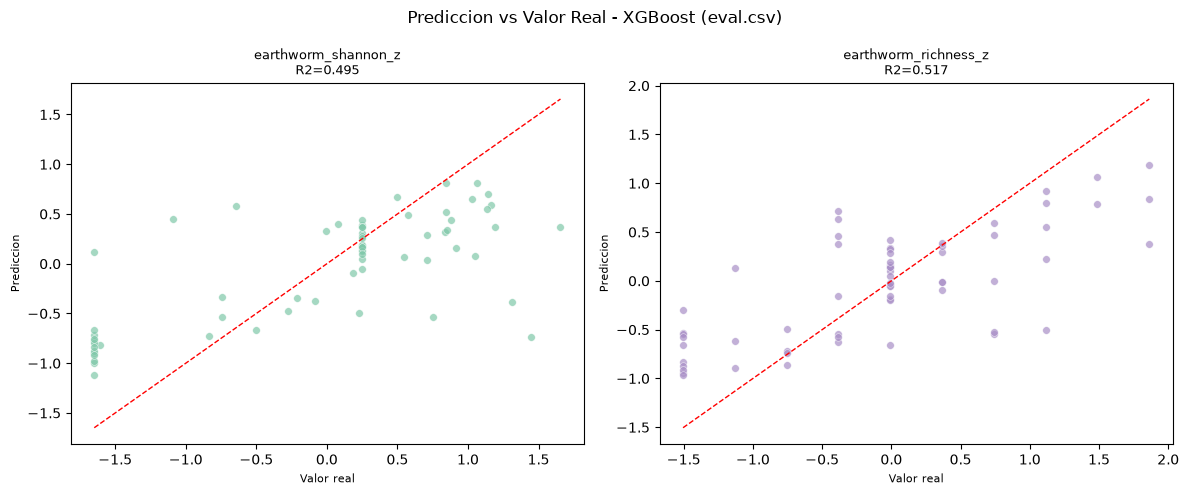

In [9]:
NUM_EXPERTOS = 5

# Evaluacion final sobre todos los targets
# Usamos eval.csv, que el modelo no ha visto hasta ahora.

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    # Cargamos los 5 modelos del target actual y promediamos sus predicciones
    preds_eval = []
    for experto_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
        model = joblib.load(ruta)
        preds_eval.append(model.predict(X_eval))

    y_pred_eval = np.mean(preds_eval, axis=0)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)


# Smoke test con datos reales
# Se prueba sobre dos targets representativos: uno shannon y uno richness.

print('Smoke test - Inferencia con datos reales')
print('-' * 65)

try:
    # Tomamos 3 filas reales al azar del dataset de evaluacion
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)

        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        # Cada uno de los 5 modelos vota con su propia prediccion para las 3 parcelas
        votos = []
        for experto_id in range(NUM_EXPERTOS):
            ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{test_target}_exp{experto_id}.pkl')
            m     = joblib.load(ruta)
            pred  = m.predict(df_new_data)
            votos.append(pred)
            print(f'  Modelo {experto_id+1} -> '
                  f'Fila {indices_elegidos[0]}: {pred[0]:.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred[1]:.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred[2]:.4f}')

        # Promediamos los 5 votos para obtener la prediccion final de consenso
        consenso = np.mean(votos, axis=0)

        print('  ' + '-' * 63)
        print('  Resultados detallados por muestra evaluada:')
        print('  ' + '-' * 63)

        for i, idx_muestra in enumerate(indices_elegidos):
            pred_val = consenso[i]
            real_val = valores_reales[i]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx_muestra:<4} | Prediccion: {pred_val:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('\nSmoke test superado. El pipeline de XGBoost funciona y predice con coherencia.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    preds = []
    for experto_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_prod_{tgt}_exp{experto_id}.pkl')
        preds.append(joblib.load(ruta).predict(X_eval))
    yp = np.mean(preds, axis=0)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - XGBoost (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()